## Import Statements

In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import re

## Parse data

In [357]:
file_pattern = "*.csv"
data_path = os.fspath("data/position/left")
data_files = glob.glob(file_pattern, root_dir=data_path)

# excluded_test_ids = {""}
excluded_test_ids = set(["left_4_4", "left_3_5"])

print(f"Found {len(data_files)} data files")
test_id_set = set()
for file_name in data_files:
    file_prefix = file_name.split("_integrated")[0]
    test_id_set.add(file_prefix)
for test_id in test_id_set:
    if test_id in excluded_test_ids:
        print(f"Unique Test ID: {test_id} : Excluded from test sets")
    else:
        print(f"Unique Test ID: {test_id} : Included in test sets")


Found 27 data files
Unique Test ID: left_3_6 : Included in test sets
Unique Test ID: left_4_5 : Included in test sets
Unique Test ID: left_2_5 : Included in test sets
Unique Test ID: left_2_6 : Included in test sets
Unique Test ID: left_3_5 : Excluded from test sets
Unique Test ID: left_4_6 : Included in test sets
Unique Test ID: left_3_7 : Included in test sets
Unique Test ID: left_2_7 : Included in test sets
Unique Test ID: left_3_4 : Included in test sets


### Append data files to Pandas dataframe

In [358]:
df_list = []
for file_name in data_files:
    file_prefix = file_name.split("_integrated")[0]
    file = os.path.join(data_path, file_name)
    print(file_name)
    temp_df = pd.read_csv(file)
    temp_df.insert(0,"test_id",file_prefix)
    df_list.append(temp_df)
data_raw = pd.concat(df_list)
display(data_raw)
display(data_raw.dtypes)

left_3_4_integrated_measurement_data_20251209_16-06-36.csv
left_3_7_integrated_measurement_data_20251209_16-14-18.csv
left_4_5_integrated_measurement_data_20251209_16-37-05.csv
left_2_5_integrated_measurement_data_20251209_16-27-15.csv
left_2_5_integrated_measurement_data_20251209_16-26-41.csv
left_4_6_integrated_measurement_data_20251209_16-31-11.csv
left_2_6_integrated_measurement_data_20251209_16-22-45.csv
left_2_7_integrated_measurement_data_20251209_16-19-11.csv
left_4_5_integrated_measurement_data_20251209_16-36-21.csv
left_2_5_integrated_measurement_data_20251209_16-27-48.csv
left_3_7_integrated_measurement_data_20251209_16-14-54.csv
left_3_6_integrated_measurement_data_20251209_15-27-52.csv
left_3_5_integrated_measurement_data_20251209_15-35-55.csv
left_3_6_integrated_measurement_data_20251209_15-28-32.csv
left_3_5_integrated_measurement_data_20251209_15-34-27.csv
left_3_4_integrated_measurement_data_20251209_16-07-21.csv
left_3_7_integrated_measurement_data_20251209_16-13-42.c

,test_id,Time (s.ms),Force_gauge (N),Linear_position (mm),strain_0.0800m (µε),strain_1.2841m (µε),strain_0.0800m (µε).1,strain_0.0807m (µε),strain_0.0813m (µε),strain_0.0820m (µε),...,marker_11_z (m),marker_12_x (m),marker_12_y (m),marker_12_z (m),marker_13_x (m),marker_13_y (m),marker_13_z (m),marker_14_x (m),marker_14_y (m),marker_14_z (m)
0,left_3_4,42.113,0.00,0.006836,-4.199999,2.900002,-4.199999,0.800000,-1.000000,-9.900000,...,-31.414454,-111.965687,-134.532955,-1.818658,-131.188180,-155.915746,-2.201826,-134.550637,-115.345762,-2.698567
1,left_3_4,42.385,0.00,0.032471,-4.400000,0.000000,-4.400000,-6.000000,-8.500000,-7.699999,...,-31.403868,-111.976456,-134.523790,-1.808534,-131.196596,-155.909394,-2.194758,-134.559832,-115.335049,-2.687451
2,left_3_4,42.659,0.00,0.058350,-2.000000,5.700001,-2.000000,-8.299999,-3.400000,2.500000,...,-31.393139,-111.975562,-134.519571,-1.792582,-131.205352,-155.905244,-2.169495,-134.556311,-115.335612,-2.673345
3,left_3_4,42.930,0.00,0.084229,2.700001,11.299999,2.700001,4.200001,3.400002,3.000000,...,-31.380435,-111.978860,-134.521636,-1.778250,-131.211405,-155.903044,-2.154438,-134.566680,-115.334764,-2.652167
4,left_3_4,43.201,0.00,0.109619,2.200001,9.700001,2.200001,-8.199999,-2.299999,-3.799999,...,-31.372618,-112.000022,-134.519216,-1.756147,-131.240064,-155.901078,-2.127949,-134.586813,-115.330302,-2.632614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,left_4_6,4.802,0.09,2.835938,9.299999,0.099998,9.299999,14.400000,1.100000,-1.699999,...,-41.207767,-165.534139,-235.064401,-1.800468,-184.110509,-256.852313,-2.560793,-188.305333,-216.122841,-2.700341
110,left_4_6,5.075,0.10,2.861572,6.500000,10.799999,6.500000,13.900000,5.600000,-3.299999,...,-41.200535,-165.523605,-235.064948,-1.823306,-184.091004,-256.858222,-2.591841,-188.292905,-216.122043,-2.724656
111,left_4_6,5.346,0.10,2.887695,1.199999,3.799999,1.199999,16.400000,3.200001,-0.500000,...,-41.188866,-165.516121,-235.069111,-1.835508,-184.090090,-256.856536,-2.592319,-188.288363,-216.125362,-2.738062
112,left_4_6,5.618,0.11,2.913086,14.700000,5.500000,14.700000,20.800000,3.200001,1.000000,...,-41.126670,-165.522390,-235.062603,-1.834798,-184.087020,-256.861423,-2.599356,-188.286362,-216.123526,-2.735507


test_id                  object
Time (s.ms)             float64
Force_gauge (N)         float64
Linear_position (mm)    float64
strain_0.0800m (µε)     float64
                         ...   
marker_13_y (m)         float64
marker_13_z (m)         float64
marker_14_x (m)         float64
marker_14_y (m)         float64
marker_14_z (m)         float64
Length: 1907, dtype: object

### Remove extra gauges and sort by position along sensor

In [359]:
data = data_raw.loc[:, ~data_raw.columns.str.contains(r"\.\d+$")]

strain_cols = [col for col in data.columns if col.startswith("strain")]
other_cols = [col for col in data.columns if col not in strain_cols]

x_axis_raw = np.array([float(re.search(r"strain_(.*)m", x).group(1)) for x in strain_cols])
sorted_idx = np.argsort(x_axis_raw)
x_axis = np.sort(x_axis_raw)
sorted_strain_cols = [strain_cols[i] for i in sorted_idx]
data = data[other_cols + sorted_strain_cols]
display(data)

,test_id,Time (s.ms),Force_gauge (N),Linear_position (mm),marker_0_x (m),marker_0_y (m),marker_0_z (m),marker_1_x (m),marker_1_y (m),marker_1_z (m),...,strain_1.2806m (µε),strain_1.2812m (µε),strain_1.2818m (µε),strain_1.2825m (µε),strain_1.2831m (µε),strain_1.2838m (µε),strain_1.2841m (µε),strain_1.2845m (µε),strain_1.2851m (µε),strain_1.2858m (µε)
0,left_3_4,42.113,0.00,0.006836,-0.594717,-0.260273,-1.692081,30.858820,-0.408874,-1.822338,...,-3.100006,-2.000000,-2.7,-5.400002,1.000000,-5.299999,2.900002,-21.599998,5.099998,2.900002
1,left_3_4,42.385,0.00,0.032471,-0.605526,-0.256514,-1.684744,30.845224,-0.398432,-1.806970,...,3.800003,1.199997,2.6,-0.500000,-1.800001,-6.899998,0.000000,-21.900002,5.000000,0.000000
2,left_3_4,42.659,0.00,0.058350,-0.613915,-0.253157,-1.663395,30.837504,-0.399006,-1.791896,...,-0.300003,-2.699997,9.5,0.099998,3.099998,-4.599998,5.700001,-14.799999,5.899998,5.700001
3,left_3_4,42.930,0.00,0.084229,-0.613836,-0.252393,-1.647848,30.832579,-0.399895,-1.774603,...,7.000000,2.800003,-1.1,-5.700001,2.000000,0.200001,11.299999,-14.299999,10.299999,11.299999
4,left_3_4,43.201,0.00,0.109619,-0.632495,-0.251935,-1.627633,30.812601,-0.398713,-1.758830,...,3.599991,16.800003,-3.6,0.299999,-3.700001,-4.399998,9.700001,-20.599998,1.199997,9.700001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,left_4_6,4.802,0.09,2.835938,-1.192803,2.214815,-2.476297,30.269884,1.860216,-2.547797,...,-7.199997,3.500000,10.0,1.799999,1.500000,-6.099998,0.099998,-12.900002,0.600002,0.099998
110,left_4_6,5.075,0.10,2.861572,-1.177756,2.238652,-2.497408,30.279228,1.881587,-2.558000,...,-3.800003,6.700005,8.2,2.199999,-4.200001,-8.399998,10.799999,-6.900002,7.500000,10.799999
111,left_4_6,5.346,0.10,2.887695,-1.176064,2.261995,-2.505648,30.280419,1.906806,-2.566640,...,-8.599991,3.599998,9.4,-6.100000,-3.600002,2.400002,3.799999,-6.000000,1.200001,3.799999
112,left_4_6,5.618,0.11,2.913086,-1.176622,2.245252,-2.507831,30.286535,1.886014,-2.570742,...,-6.699997,0.500000,-3.6,-9.500000,6.500000,7.300003,5.500000,-4.200001,-6.700001,5.500000


## Data Processing

### Visualize strain ranges

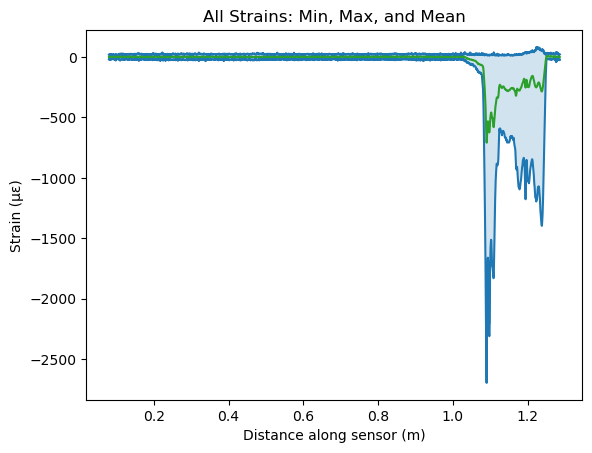

In [360]:
upper_bound = data[sorted_strain_cols].max()
lower_bound = data[sorted_strain_cols].min()
mean_line = data[sorted_strain_cols].mean()

fig, ax = plt.subplots()
ax.plot(x_axis,upper_bound,color='tab:blue')
ax.plot(x_axis,lower_bound,color='tab:blue')
ax.plot(x_axis,mean_line,color='tab:green')
ax.fill_between(x_axis,upper_bound,lower_bound,alpha=0.2)
ax.set_title("All Strains: Min, Max, and Mean")
ax.set_ylabel("Strain (με)")
ax.set_xlabel("Distance along sensor (m)")
plt.show()

### Cutoff excess early data

,strain_1.0199m (µε),strain_1.0206m (µε),strain_1.0212m (µε),strain_1.0218m (µε),strain_1.0225m (µε),strain_1.0231m (µε),strain_1.0238m (µε),strain_1.0244m (µε),strain_1.0251m (µε),strain_1.0258m (µε),...,strain_1.2806m (µε),strain_1.2812m (µε),strain_1.2818m (µε),strain_1.2825m (µε),strain_1.2831m (µε),strain_1.2838m (µε),strain_1.2841m (µε),strain_1.2845m (µε),strain_1.2851m (µε),strain_1.2858m (µε)
0,10.700001,-1.400002,-4.500000,-4.200001,-2.700001,-2.200001,12.500000,-1.300003,-1.099998,-1.600002,...,-3.100006,-2.000000,-2.7,-5.400002,1.000000,-5.299999,2.900002,-21.599998,5.099998,2.900002
1,0.900002,-0.200001,-3.700001,-2.900002,1.799999,-0.200001,3.399998,1.000000,5.900002,0.200001,...,3.800003,1.199997,2.6,-0.500000,-1.800001,-6.899998,0.000000,-21.900002,5.000000,0.000000
2,3.299999,1.899998,1.500000,-0.900002,-5.799999,-4.600002,3.599998,2.399998,2.700001,-3.000000,...,-0.300003,-2.699997,9.5,0.099998,3.099998,-4.599998,5.700001,-14.799999,5.899998,5.700001
3,-3.299999,-6.600002,1.799999,0.599998,2.799999,-6.400002,11.599998,6.899998,2.200001,0.200001,...,7.000000,2.800003,-1.1,-5.700001,2.000000,0.200001,11.299999,-14.299999,10.299999,11.299999
4,2.000000,0.099998,4.600002,4.700001,-1.099998,-5.300003,2.500000,2.299999,4.300003,-2.700001,...,3.599991,16.800003,-3.6,0.299999,-3.700001,-4.399998,9.700001,-20.599998,1.199997,9.700001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,-10.400002,3.000000,7.500000,-11.299999,-3.399998,-5.200001,-11.899998,6.000000,-5.500000,-10.899998,...,-7.199997,3.500000,10.0,1.799999,1.500000,-6.099998,0.099998,-12.900002,0.600002,0.099998
110,-2.400002,0.700001,0.799999,-15.500000,-6.500000,-9.700001,-16.799999,-2.299999,-4.299999,-4.399998,...,-3.800003,6.700005,8.2,2.199999,-4.200001,-8.399998,10.799999,-6.900002,7.500000,10.799999
111,-10.000000,-0.700001,10.700001,-3.099998,-4.799999,-7.000000,-16.799999,-6.299999,-5.099998,-1.500000,...,-8.599991,3.599998,9.4,-6.100000,-3.600002,2.400002,3.799999,-6.000000,1.200001,3.799999
112,-6.099998,-6.899998,11.500000,-9.599998,-7.200001,-8.700001,-15.599998,3.299999,-0.799999,-8.700001,...,-6.699997,0.500000,-3.6,-9.500000,6.500000,7.300003,5.500000,-4.200001,-6.700001,5.500000


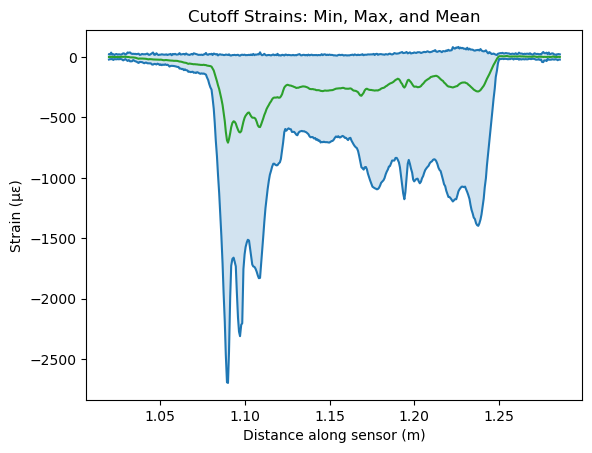

In [361]:
start_location = 1.02
cutoff_idx = (np.abs(x_axis - start_location)).argmin()
cutoff_strain = data[sorted_strain_cols].iloc[:,cutoff_idx:]
cutoff_x_axis = x_axis[cutoff_idx:]

upper_bound = cutoff_strain.max()
lower_bound = cutoff_strain.min()
mean_line = cutoff_strain.mean()

fig, ax = plt.subplots()
ax.plot(cutoff_x_axis,upper_bound,color='tab:blue')
ax.plot(cutoff_x_axis,lower_bound,color='tab:blue')
ax.plot(cutoff_x_axis,mean_line,color='tab:green')
ax.fill_between(cutoff_x_axis,upper_bound,lower_bound,alpha=0.2)
ax.set_title("Cutoff Strains: Min, Max, and Mean")
ax.set_ylabel("Strain (με)")
ax.set_xlabel("Distance along sensor (m)")
display(cutoff_strain)
plt.show()

### Remove NAN values

In [362]:
display(cutoff_strain.isna().sum().sum())
cutoff_strain.interpolate(inplace=True, axis=0)
cutoff_strain.interpolate(inplace=True, axis=1)
display(cutoff_strain.isna().sum().sum())

np.int64(0)

np.int64(0)

Custom cv

In [363]:
cv_split_array = np.zeros(len(data.test_id))
test_id_array = data.test_id.to_numpy()
i = 0
test_id_names = []
for test_id in test_id_set:
    if test_id in excluded_test_ids:
        split_idx = -1
    else:
        split_idx = i
        test_id_names.append(test_id)
        i += 1
    cv_split_array = np.where(test_id_array == test_id, split_idx, cv_split_array)
print(f"Generated {i} test sets")
print(f"{data["test_id"].value_counts()}")
for test_id in test_id_names:
    test_id_rows = data.loc[data['test_id'] == test_id]


Generated 8 test sets
test_id
left_3_4    375
left_4_5    371
left_3_5    370
left_4_6    341
left_3_6    328
left_3_7    281
left_2_6    267
left_2_5    250
left_2_7    249
Name: count, dtype: int64


## Visualize Vicon Data

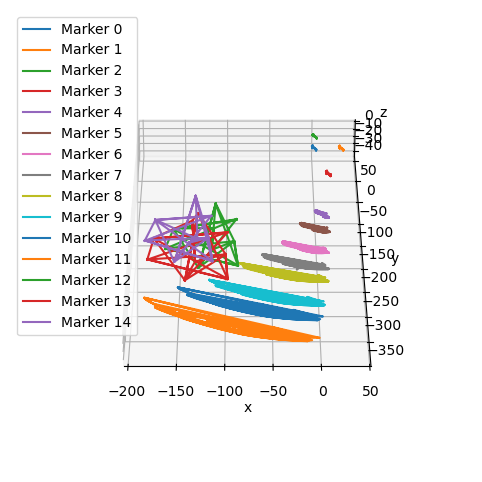

In [364]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
for i in range(15):
    x = data[f"marker_{i}_x (m)"]
    y = data[f"marker_{i}_y (m)"]
    z = data[f"marker_{i}_z (m)"]
    ax.plot(x,y,z, label=f"Marker {i}")
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.view_init( azim=-90)
ax.legend(loc="upper left")
plt.show()

## Geometric Parameters

In [365]:
# Dimensions in mm
manipulator_width = 15
sensor_length = 26.75

## 2D Contact Representation

In [366]:
sensor_base_x = data["marker_14_x (m)"]
sensor_base_y = data["marker_14_y (m)"]
sensor_base = np.array([sensor_base_x, sensor_base_y])
sensor_end_x = data["marker_12_x (m)"]
sensor_end_y = data["marker_12_y (m)"]
sensor_end = np.array([sensor_end_x, sensor_end_y])
sensor_delta = sensor_end - sensor_base
sensor_tip = sensor_end + sensor_length * (sensor_delta / 14.16)
data["sensor_tip_x"] = sensor_tip[0,:]
data["sensor_tip_y"] = sensor_tip[1,:]

contact_pos_x = np.empty((len(data)))
contact_pos_y = np.empty((len(data)))
contact_t = np.empty((len(data)))
contact_dist = np.full((len(data)),np.inf)

for i in range(4,12):
    marker_pos = np.array([data[f"marker_{i}_x (m)"], data[f"marker_{i}_y (m)"]])
    if i == 4:
        prev_marker_pos = marker_pos + np.array([0,1])[:, np.newaxis]
    else:
        prev_marker_pos = np.array([data[f"marker_{i-1}_x (m)"], data[f"marker_{i-1}_y (m)"]])
    delta = marker_pos - prev_marker_pos
    delta_u = delta / np.linalg.norm(delta,axis=0)
    normal = np.array([-np.array(delta_u[1,:]), delta_u[0,:]])
    left_marker_pos = marker_pos - manipulator_width*normal/2
    right_marker_pos = marker_pos + manipulator_width*normal/2
    data[f"left_marker_{i}_x"] = left_marker_pos[0]
    data[f"left_marker_{i}_y"] = left_marker_pos[1]
    data[f"right_marker_{i}_x"] = right_marker_pos[0]
    data[f"right_marker_{i}_y"] = right_marker_pos[1]

    A = np.array([sensor_delta, -delta_u]).T

    b_left = (left_marker_pos - sensor_tip).T
    y_left = np.linalg.solve(A, b_left[:,:,np.newaxis])
    b_right = (right_marker_pos - sensor_tip).T
    y_right = np.linalg.solve(A, b_right[:,:,np.newaxis])

    contact_left = left_marker_pos + y_left[:,1].T*delta_u
    contact_right = right_marker_pos + y_right[:,1].T*delta_u
    contact_dist_left = np.linalg.norm(sensor_tip - contact_left, axis=0)
    contact_dist_right = np.linalg.norm(sensor_tip - contact_right, axis=0)

    for j, _ in enumerate(contact_dist):
        if contact_dist_left[j] < contact_dist[j]:
            contact_dist[j] = contact_dist_left[j]
            contact_pos_x[j] = contact_left[0,j]
            contact_pos_y[j] = contact_left[1,j]
            contact_t[j] = i - 4 + y_left[j,1,0]/np.linalg.norm(delta,axis=0)[j]


0     -134.550637
1     -134.559832
2     -134.556311
3     -134.566680
4     -134.586813
          ...    
109   -188.305333
110   -188.292905
111   -188.288363
112   -188.286362
113   -188.297184
Name: marker_14_x (m), Length: 2832, dtype: float64


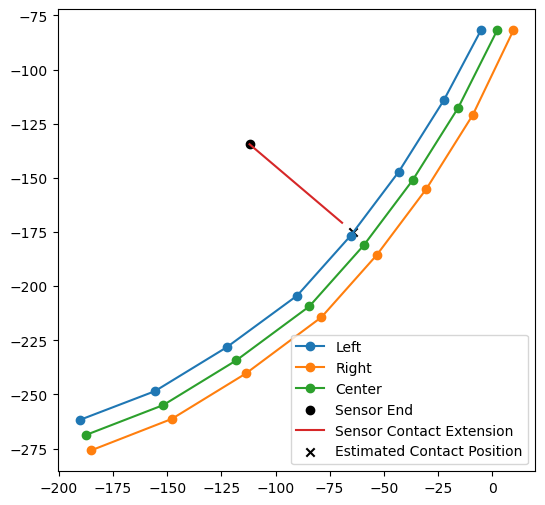

In [367]:
row = np.argmax(data["Force_gauge (N)"])
left_x_data = [data.iloc[row][f"left_marker_{i}_x"] for i in range(4,12)]
left_y_data = [data.iloc[row][f"left_marker_{i}_y"] for i in range(4,12)]
right_x_data = [data.iloc[row][f"right_marker_{i}_x"] for i in range(4,12)]
right_y_data = [data.iloc[row][f"right_marker_{i}_y"] for i in range(4,12)]
center_x_data = [data.iloc[row][f"marker_{i}_x (m)"] for i in range(4,12)]
center_y_data = [data.iloc[row][f"marker_{i}_y (m)"] for i in range(4,12)]

sensor_end_x = data.iloc[row]["marker_12_x (m)"]
sensor_end_y = data.iloc[row]["marker_12_y (m)"]
sensor_tip_x = data.iloc[row]["sensor_tip_x"]
sensor_tip_y = data.iloc[row]["sensor_tip_y"]
fig = plt.figure(figsize=(16,6))
ax = fig.add_subplot()

ax.plot(left_x_data, left_y_data, "o-")
# ax.scatter(left_x_data, left_y_data)

ax.plot(right_x_data, right_y_data, "o-")
# ax.scatter(right_x_data, right_y_data)

ax.plot(center_x_data, center_y_data, "o-")
# ax.scatter(center_x_data, center_y_data)
# ax.scatter(sensor_base_x[row], sensor_base_y[row], color="black")
print(sensor_base_x)
ax.scatter(sensor_end_x, sensor_end_y, color="black", marker='o')
ax.plot([sensor_end_x, sensor_tip_x], [sensor_end_y, sensor_tip_y])
ax.scatter(contact_pos_x[row], contact_pos_y[row], marker='x', color='black')

ax.set_aspect('equal')
ax.legend(["Left","Right","Center", "Sensor End", "Sensor Contact Extension", "Estimated Contact Position"])
plt.show()
# print(contact_t[row])


In [368]:
data["contact_dist"] = contact_dist
data["contact_t"] = contact_t
display(data[["Time (s.ms)","Force_gauge (N)", "sensor_tip_x","sensor_tip_y","contact_dist","contact_t"]])

,Time (s.ms),Force_gauge (N),sensor_tip_x,sensor_tip_y,contact_dist,contact_t
0,42.113,0.00,-69.299911,-170.779947,88.740987,3.409042
1,42.385,0.00,-69.313651,-170.773707,88.749122,3.409287
2,42.659,0.00,-69.317720,-170.760453,88.746418,3.408690
3,42.930,0.00,-69.307661,-170.768022,88.716062,3.408548
4,43.201,0.00,-69.330767,-170.769459,88.688115,3.408452
...,...,...,...,...,...,...
109,4.802,0.09,-122.516523,-270.847361,8.461956,5.896844
110,5.075,0.10,-122.509568,-270.850449,8.497484,5.901039
111,5.346,0.10,-122.496526,-270.856208,8.528616,5.905490
112,5.618,0.11,-122.518417,-270.840875,8.589238,5.910367


In [369]:
contact_force_threshold = 0.01
data.loc[data["Force_gauge (N)"] < contact_force_threshold, "contact_t"] = np.nan

display(data[["Time (s.ms)","Force_gauge (N)", "sensor_tip_x","sensor_tip_y","contact_dist","contact_t"]])

,Time (s.ms),Force_gauge (N),sensor_tip_x,sensor_tip_y,contact_dist,contact_t
0,42.113,0.00,-69.299911,-170.779947,88.740987,NaN
1,42.385,0.00,-69.313651,-170.773707,88.749122,NaN
2,42.659,0.00,-69.317720,-170.760453,88.746418,NaN
3,42.930,0.00,-69.307661,-170.768022,88.716062,NaN
4,43.201,0.00,-69.330767,-170.769459,88.688115,NaN
...,...,...,...,...,...,...
109,4.802,0.09,-122.516523,-270.847361,8.461956,5.896844
110,5.075,0.10,-122.509568,-270.850449,8.497484,5.901039
111,5.346,0.10,-122.496526,-270.856208,8.528616,5.905490
112,5.618,0.11,-122.518417,-270.840875,8.589238,5.910367


Found 27 data files


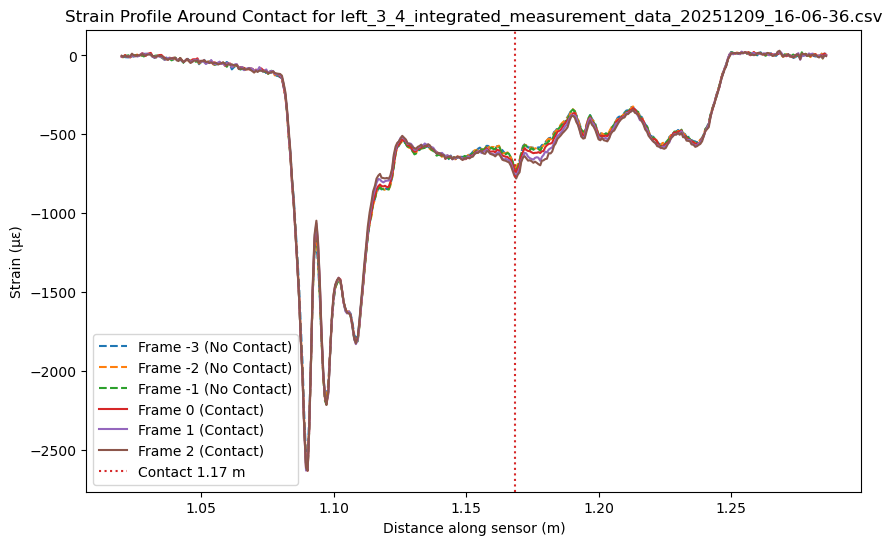

Frame details for left_3_4_integrated_measurement_data_20251209_16-06-36.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
105,-3,10.672,0.00
106,-2,10.948,0.00
107,-1,11.216,0.00
108,0,11.488,0.02
109,1,11.761,0.02
110,2,12.032,0.03


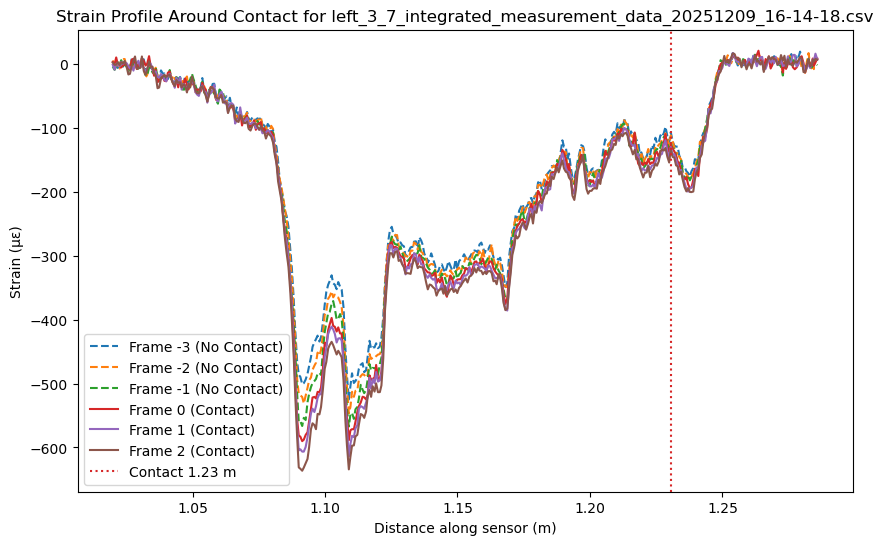

Frame details for left_3_7_integrated_measurement_data_20251209_16-14-18.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
45,-3,36.040,0.00
46,-2,36.312,0.00
47,-1,36.585,0.00
48,0,36.856,0.01
49,1,37.128,0.01
50,2,37.400,0.01


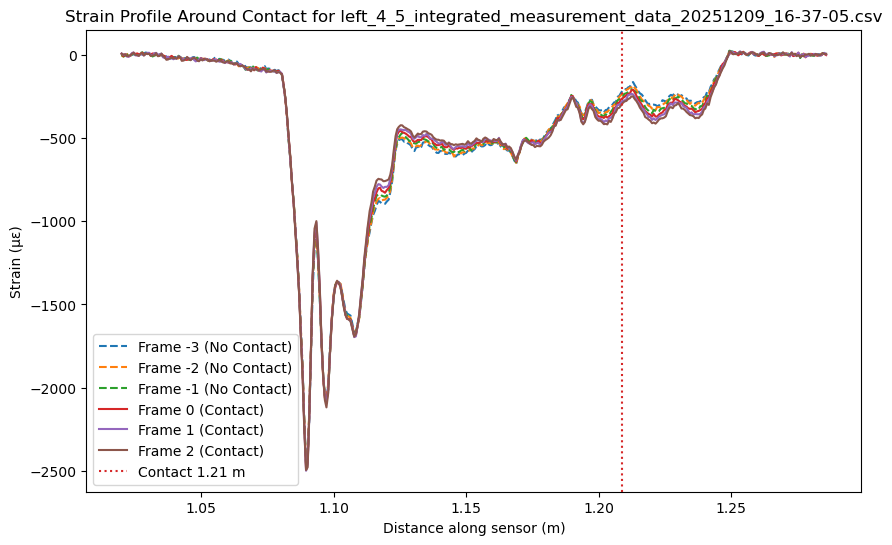

Frame details for left_4_5_integrated_measurement_data_20251209_16-37-05.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
91,-3,35.650,-0.01
92,-2,35.922,0.00
93,-1,36.194,0.00
94,0,36.467,0.01
95,1,36.738,0.01
96,2,37.010,0.01


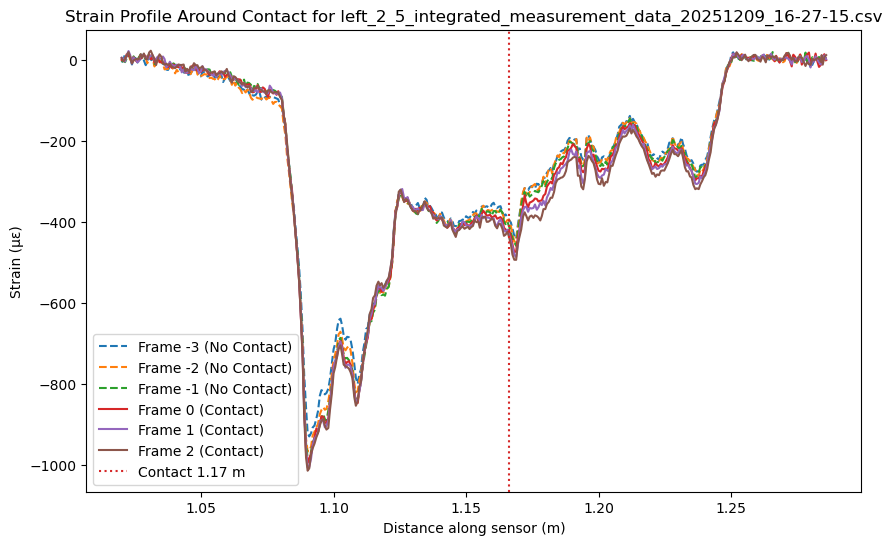

Frame details for left_2_5_integrated_measurement_data_20251209_16-27-15.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
57,-3,36.122,0.00
58,-2,36.394,0.00
59,-1,36.666,0.00
60,0,36.938,0.01
61,1,37.210,0.02
62,2,37.482,0.02


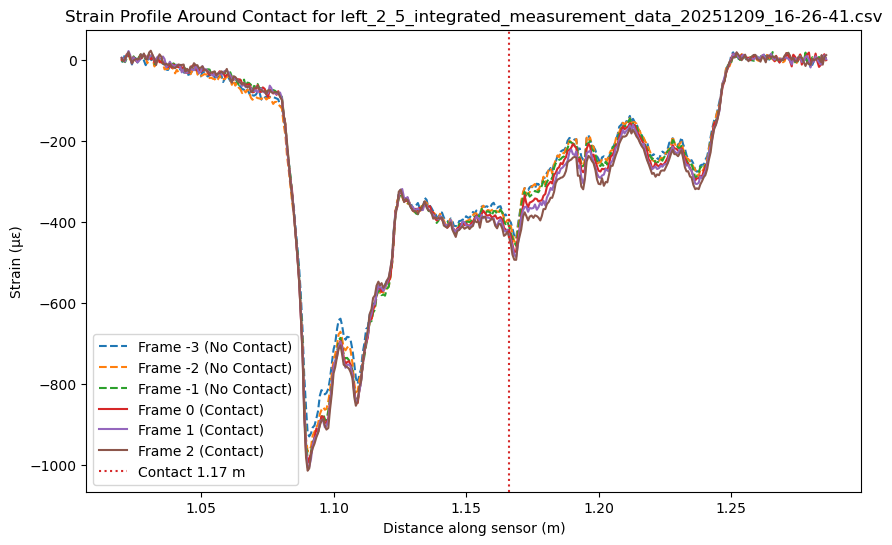

Frame details for left_2_5_integrated_measurement_data_20251209_16-26-41.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
57,-3,36.122,0.00
58,-2,36.394,0.00
59,-1,36.666,0.00
60,0,36.938,0.01
61,1,37.210,0.02
62,2,37.482,0.02


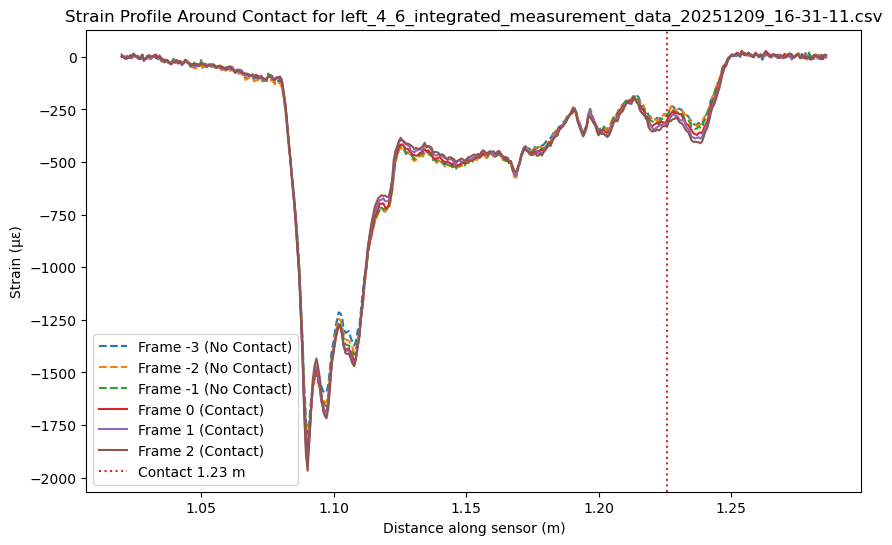

Frame details for left_4_6_integrated_measurement_data_20251209_16-31-11.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
77,-3,37.649,0.00
78,-2,37.920,0.00
79,-1,38.193,0.00
80,0,38.464,0.01
81,1,38.737,0.01
82,2,39.008,0.02


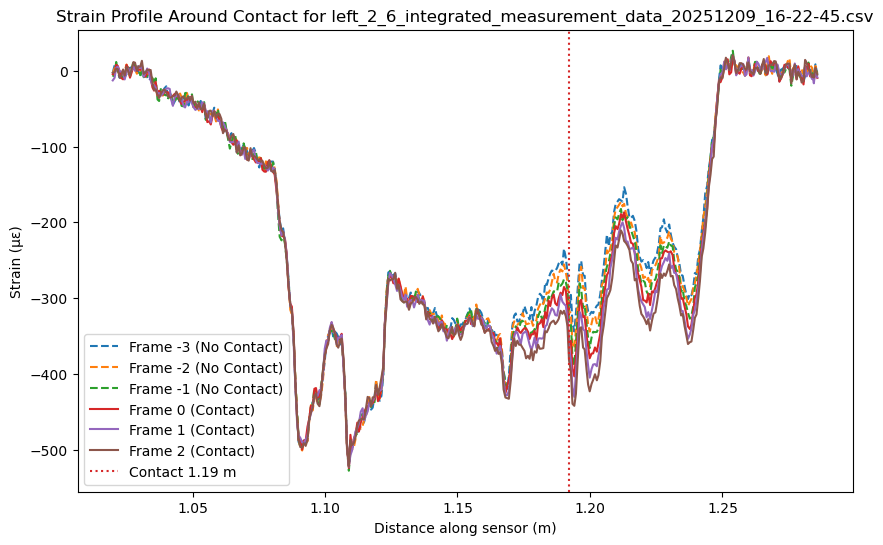

Frame details for left_2_6_integrated_measurement_data_20251209_16-22-45.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
55,-3,5.926,0.00
56,-2,6.198,0.00
57,-1,6.472,0.00
58,0,6.742,0.01
59,1,7.014,0.01
60,2,7.302,0.01


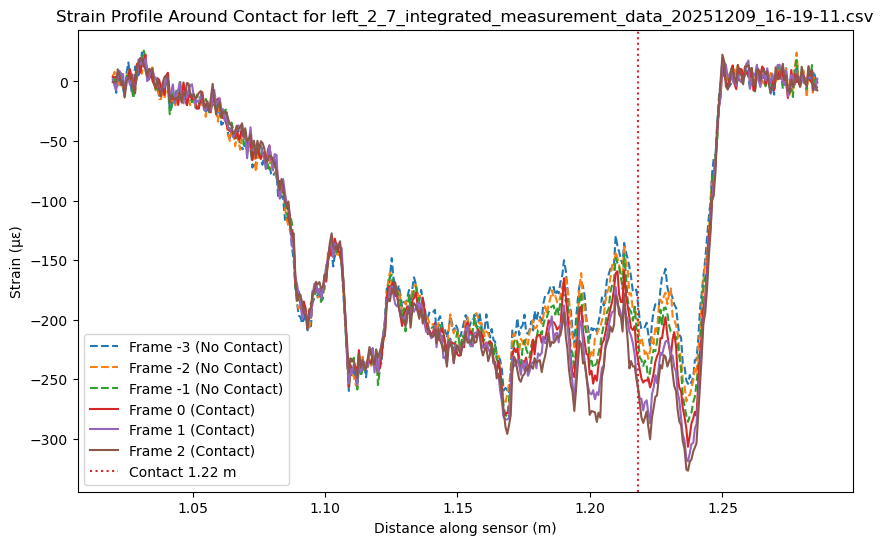

Frame details for left_2_7_integrated_measurement_data_20251209_16-19-11.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
39,-3,27.783,0.00
40,-2,28.059,0.00
41,-1,28.327,0.00
42,0,28.599,0.01
43,1,28.871,0.01
44,2,29.143,0.01


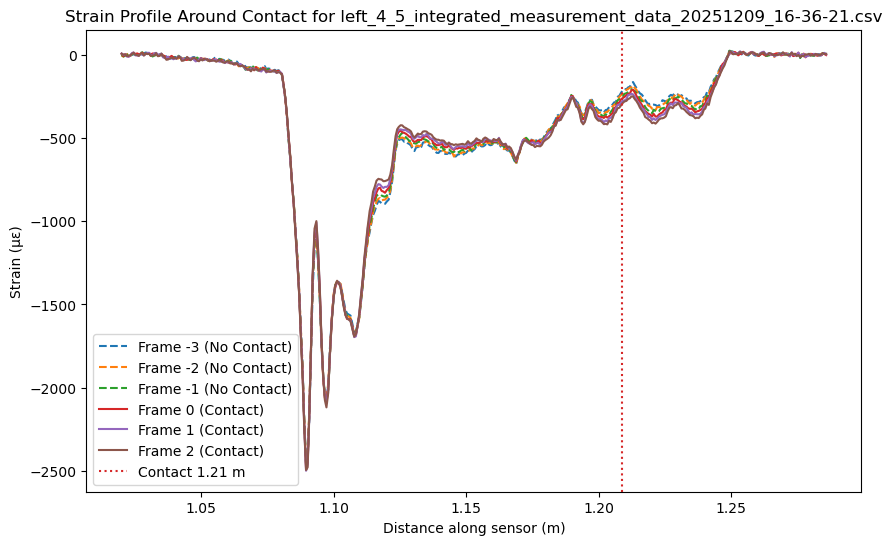

Frame details for left_4_5_integrated_measurement_data_20251209_16-36-21.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
91,-3,35.650,-0.01
92,-2,35.922,0.00
93,-1,36.194,0.00
94,0,36.467,0.01
95,1,36.738,0.01
96,2,37.010,0.01


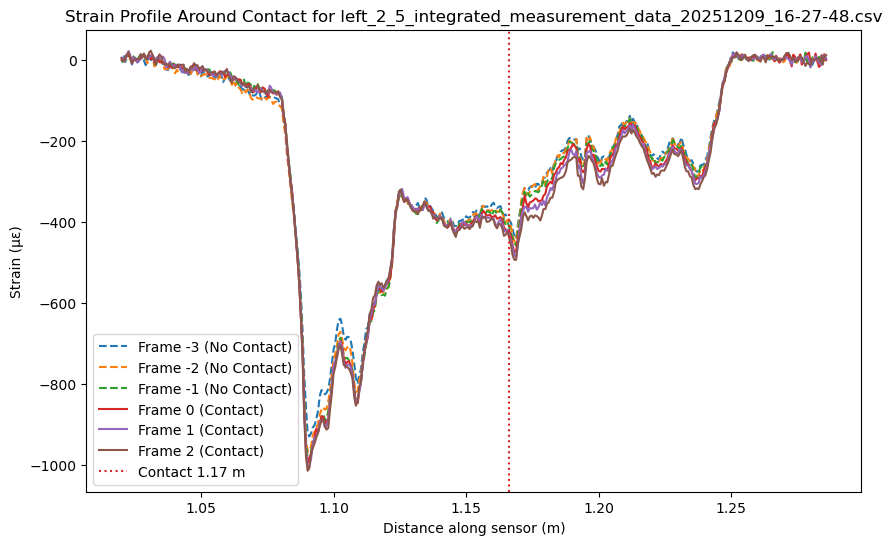

Frame details for left_2_5_integrated_measurement_data_20251209_16-27-48.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
57,-3,36.122,0.00
58,-2,36.394,0.00
59,-1,36.666,0.00
60,0,36.938,0.01
61,1,37.210,0.02
62,2,37.482,0.02


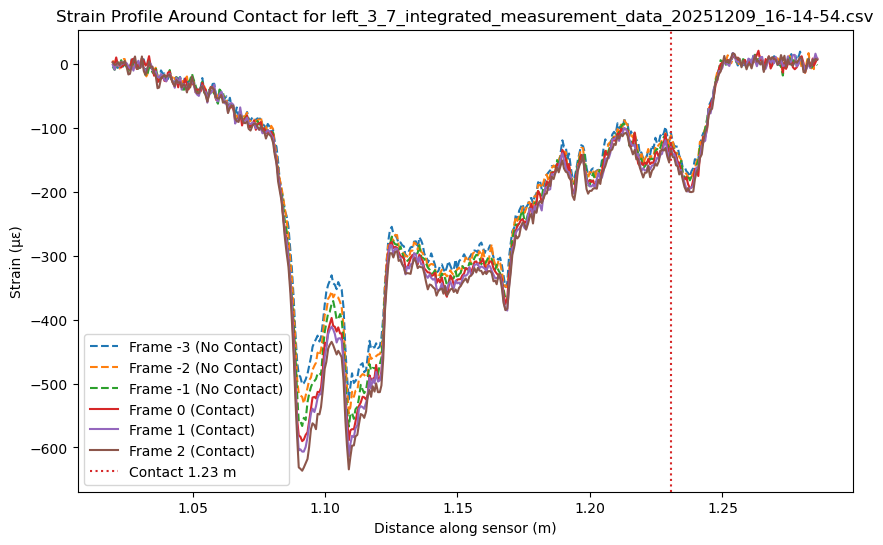

Frame details for left_3_7_integrated_measurement_data_20251209_16-14-54.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
45,-3,36.040,0.00
46,-2,36.312,0.00
47,-1,36.585,0.00
48,0,36.856,0.01
49,1,37.128,0.01
50,2,37.400,0.01


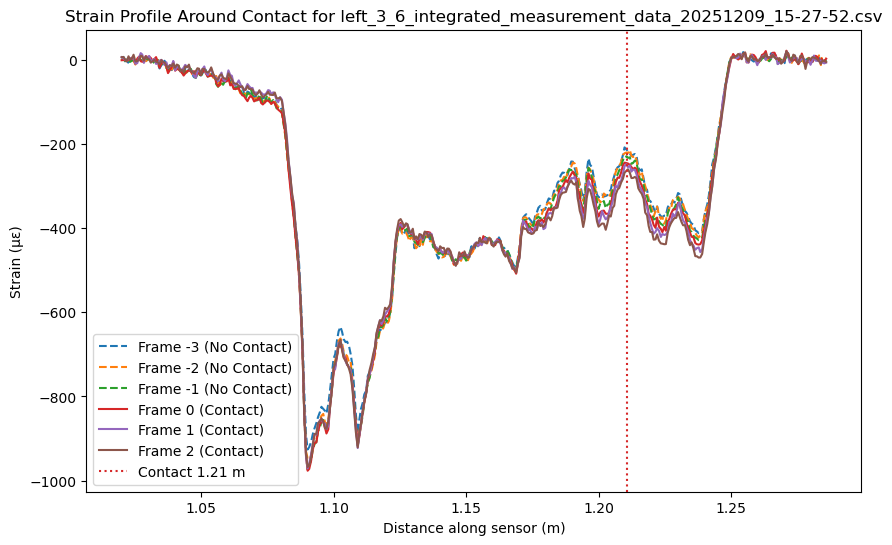

Frame details for left_3_6_integrated_measurement_data_20251209_15-27-52.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
73,-3,17.551,0.00
74,-2,17.822,0.00
75,-1,18.094,0.00
76,0,18.366,0.01
77,1,18.639,0.01
78,2,18.911,0.01


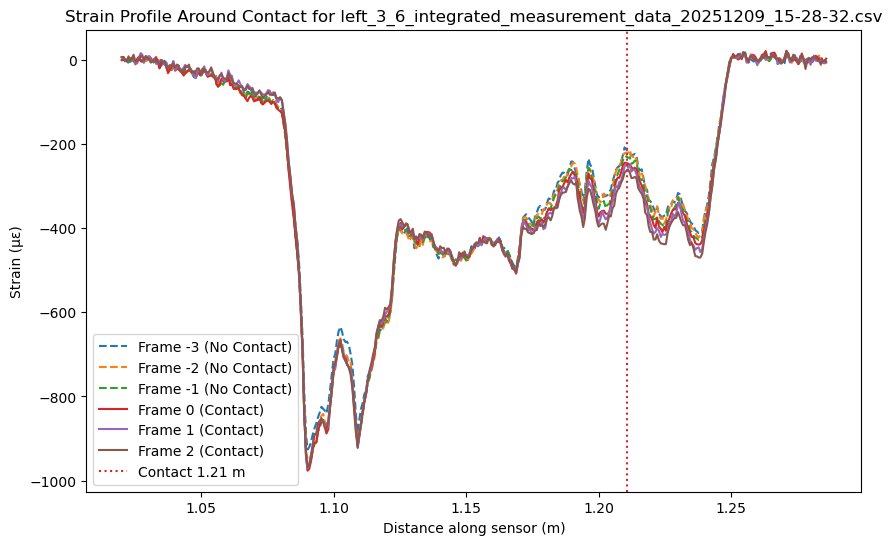

Frame details for left_3_6_integrated_measurement_data_20251209_15-28-32.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
73,-3,17.551,0.00
74,-2,17.822,0.00
75,-1,18.094,0.00
76,0,18.366,0.01
77,1,18.639,0.01
78,2,18.911,0.01


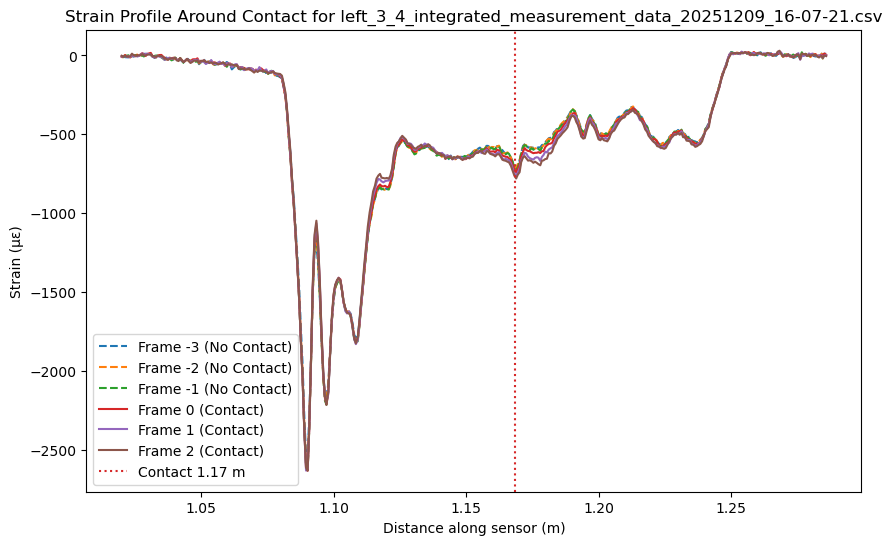

Frame details for left_3_4_integrated_measurement_data_20251209_16-07-21.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
105,-3,10.672,0.00
106,-2,10.948,0.00
107,-1,11.216,0.00
108,0,11.488,0.02
109,1,11.761,0.02
110,2,12.032,0.03


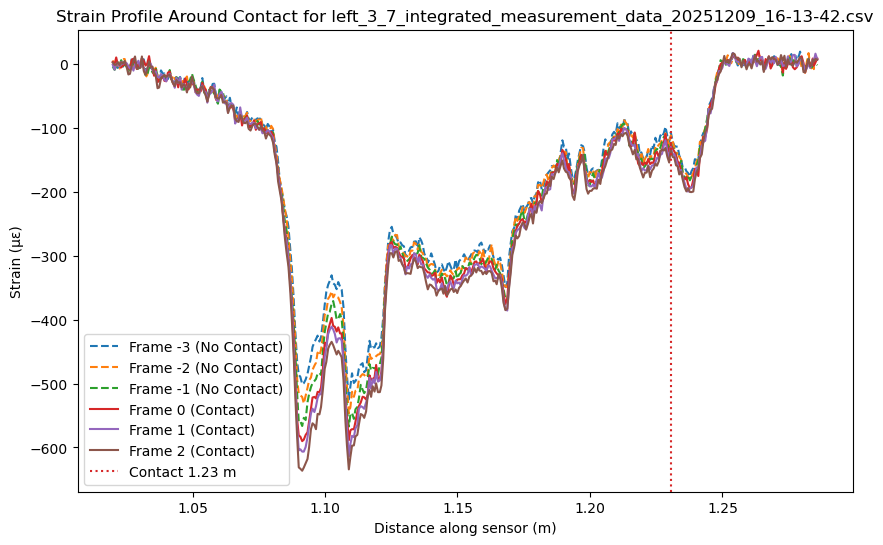

Frame details for left_3_7_integrated_measurement_data_20251209_16-13-42.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
45,-3,36.040,0.00
46,-2,36.312,0.00
47,-1,36.585,0.00
48,0,36.856,0.01
49,1,37.128,0.01
50,2,37.400,0.01


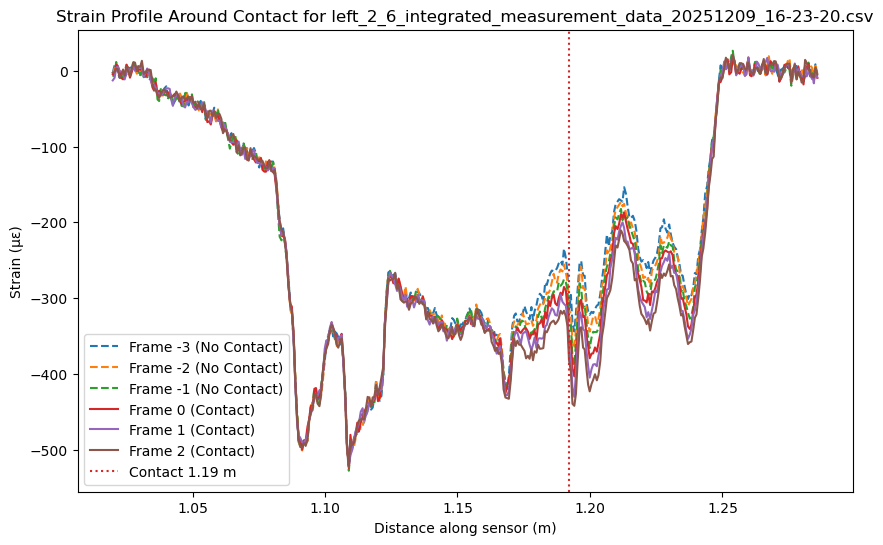

Frame details for left_2_6_integrated_measurement_data_20251209_16-23-20.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
55,-3,5.926,0.00
56,-2,6.198,0.00
57,-1,6.472,0.00
58,0,6.742,0.01
59,1,7.014,0.01
60,2,7.302,0.01


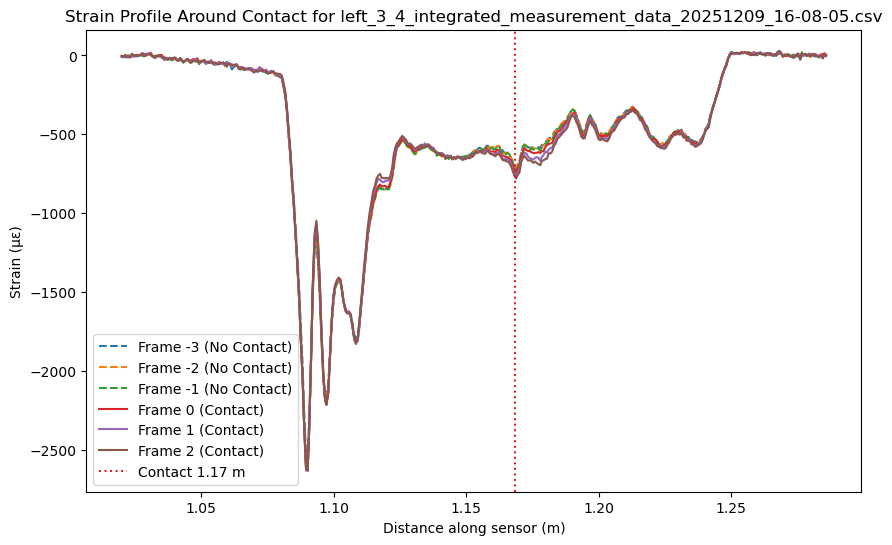

Frame details for left_3_4_integrated_measurement_data_20251209_16-08-05.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
105,-3,10.672,0.00
106,-2,10.948,0.00
107,-1,11.216,0.00
108,0,11.488,0.02
109,1,11.761,0.02
110,2,12.032,0.03


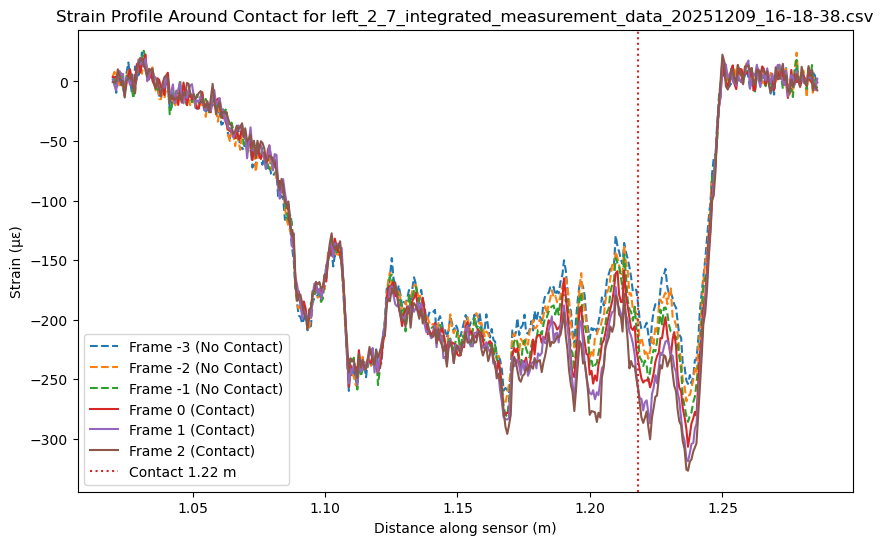

Frame details for left_2_7_integrated_measurement_data_20251209_16-18-38.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
39,-3,27.783,0.00
40,-2,28.059,0.00
41,-1,28.327,0.00
42,0,28.599,0.01
43,1,28.871,0.01
44,2,29.143,0.01


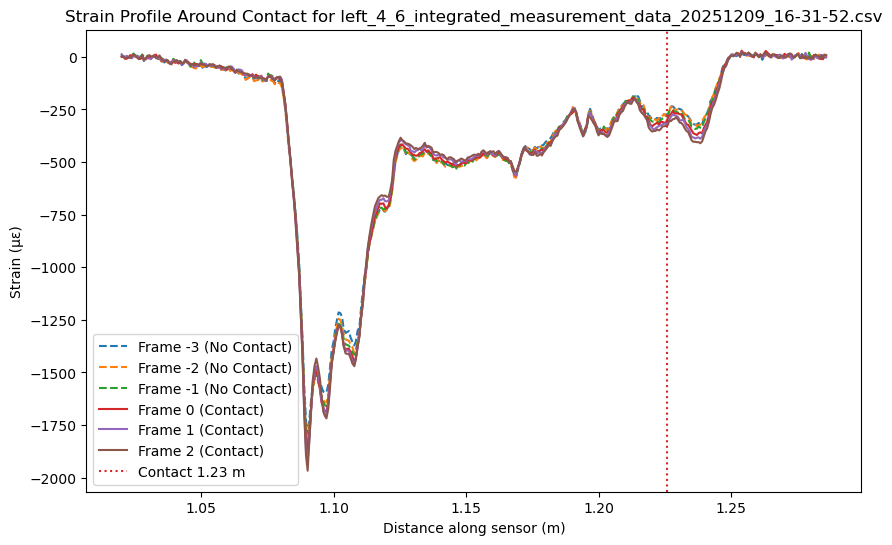

Frame details for left_4_6_integrated_measurement_data_20251209_16-31-52.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
77,-3,37.649,0.00
78,-2,37.920,0.00
79,-1,38.193,0.00
80,0,38.464,0.01
81,1,38.737,0.01
82,2,39.008,0.02


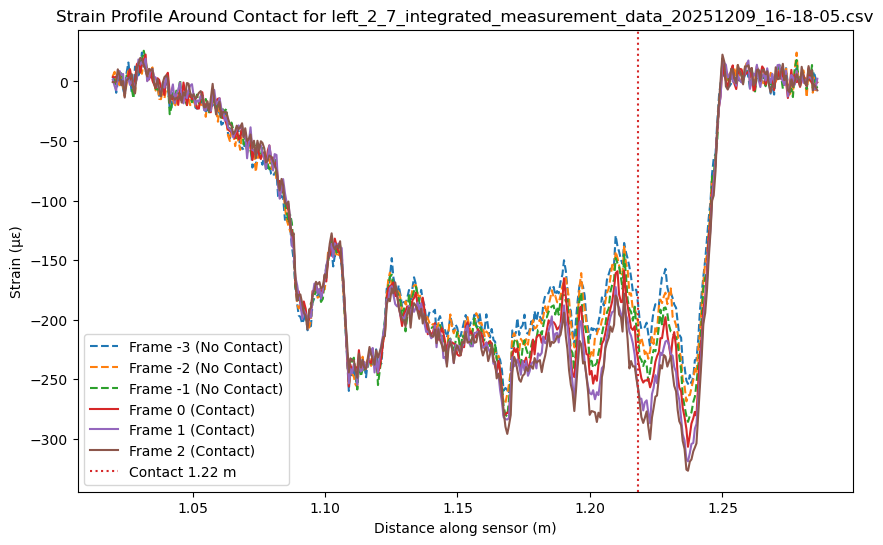

Frame details for left_2_7_integrated_measurement_data_20251209_16-18-05.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
39,-3,27.783,0.00
40,-2,28.059,0.00
41,-1,28.327,0.00
42,0,28.599,0.01
43,1,28.871,0.01
44,2,29.143,0.01


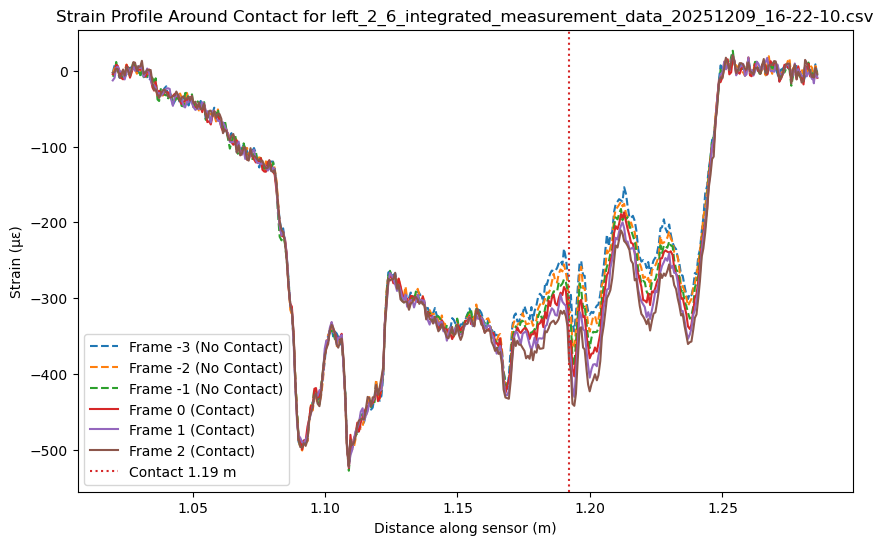

Frame details for left_2_6_integrated_measurement_data_20251209_16-22-10.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
55,-3,5.926,0.00
56,-2,6.198,0.00
57,-1,6.472,0.00
58,0,6.742,0.01
59,1,7.014,0.01
60,2,7.302,0.01


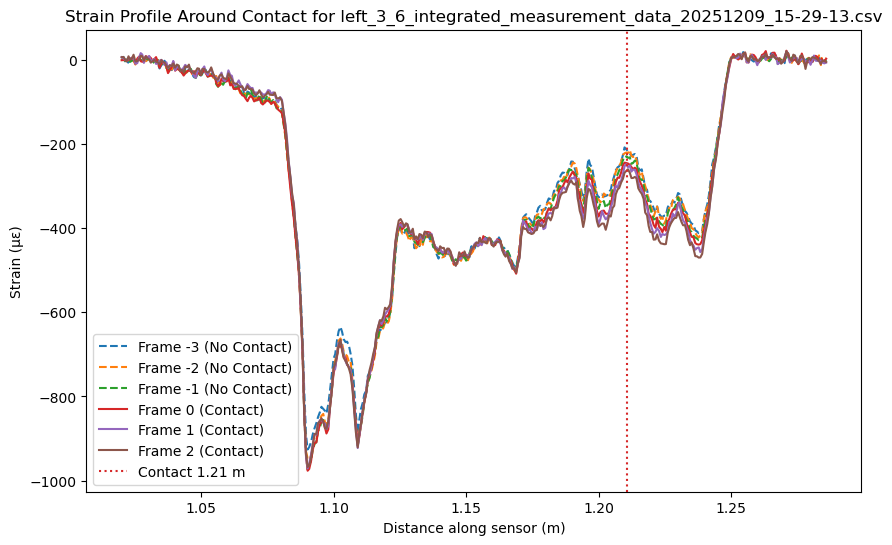

Frame details for left_3_6_integrated_measurement_data_20251209_15-29-13.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
73,-3,17.551,0.00
74,-2,17.822,0.00
75,-1,18.094,0.00
76,0,18.366,0.01
77,1,18.639,0.01
78,2,18.911,0.01


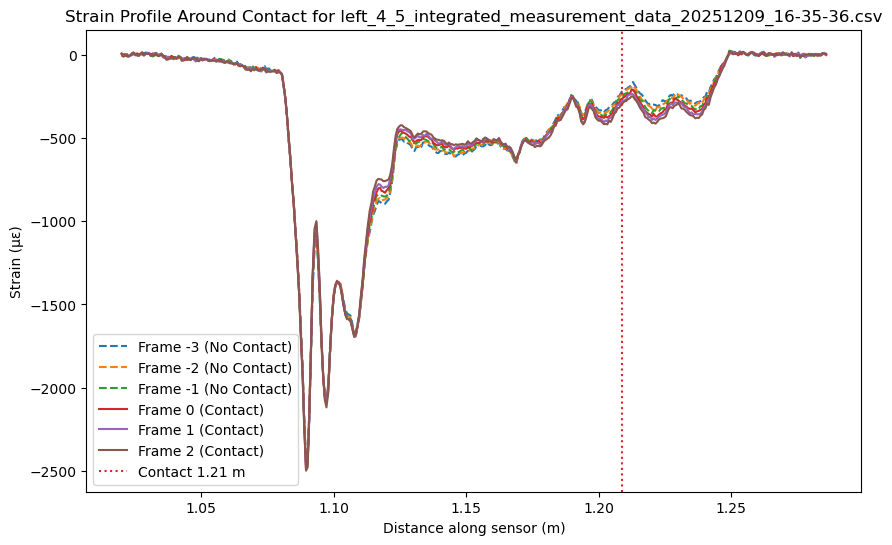

Frame details for left_4_5_integrated_measurement_data_20251209_16-35-36.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
91,-3,35.650,-0.01
92,-2,35.922,0.00
93,-1,36.194,0.00
94,0,36.467,0.01
95,1,36.738,0.01
96,2,37.010,0.01


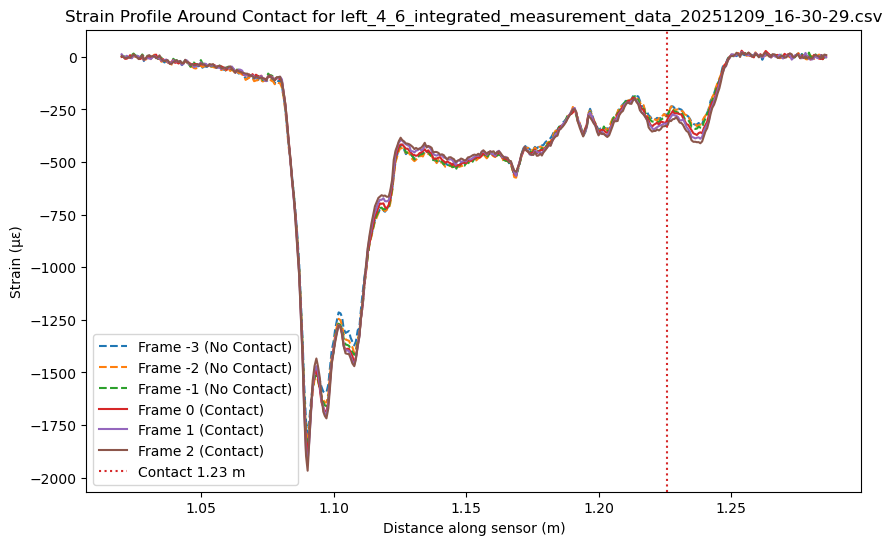

Frame details for left_4_6_integrated_measurement_data_20251209_16-30-29.csv:


,Relative_Frame,Time (s.ms),Force_gauge (N)
77,-3,37.649,0.00
78,-2,37.920,0.00
79,-1,38.193,0.00
80,0,38.464,0.01
81,1,38.737,0.01
82,2,39.008,0.02


In [ ]:
print(f"Found {len(data_files)} data files")

contact_force_threshold = 0.01

for file_name in data_files:
    file_prefix = file_name.split("_integrated")[0]
    if file_prefix in excluded_test_ids:
        continue
    file_mask = data['test_id'] == file_prefix
    strain_subset = cutoff_strain.loc[file_mask]
    force_subset = data.loc[file_mask, 'Force_gauge (N)']

    # Find where contact starts
    is_contact = (force_subset >= contact_force_threshold).to_numpy()
    contact_indices = np.where(is_contact)[0]

    if len(contact_indices) == 0:
        continue
    
    # Start of contact index
    start_contact_idx = contact_indices[0]

    # Contact location (constant per test_id; only defined when force is positive)
    contact_t_vals = data.loc[file_mask & (data['Force_gauge (N)'] >= contact_force_threshold), 'contact_t']
    if not contact_t_vals.empty:
        contact_t_val = contact_t_vals.iloc[0]
    else:
        contact_t_val = np.nan
    contact_loc = 1.11 + contact_t_val * 0.02

    # Range for plotting
    pre_contact_indices = range(start_contact_idx - 3, start_contact_idx)
    post_contact_indices = range(start_contact_idx, start_contact_idx + 3)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot frames before contact
    for i in pre_contact_indices:
        if 0 <= i < len(strain_subset):
            ax.plot(cutoff_x_axis, strain_subset.iloc[i], label=f'Frame {i - start_contact_idx} (No Contact)', linestyle='--')

    # Plot frames after/during contact
    for i in post_contact_indices:
        if 0 <= i < len(strain_subset):
            ax.plot(cutoff_x_axis, strain_subset.iloc[i], label=f'Frame {i - start_contact_idx} (Contact)')

    if np.isfinite(contact_loc):
        ax.axvline(contact_loc, color='tab:red', linestyle=':', label=f'Contact {contact_loc:.2f} m')

    ax.set_title(f"Strain Profile Around Contact for {file_name}")
    ax.set_xlabel("Distance along sensor (m)")
    ax.set_ylabel("Strain (με)")
    ax.legend()
    plt.show()
    
    # ----------- save plot ----------
    # output_dir = "plot"
    # os.makedirs(output_dir, exist_ok=True)
    # out_path = os.path.join(output_dir, f"{file_name}_strain_contact.png")
    # fig.savefig(out_path, dpi=300, bbox_inches="tight")
    
    print(f"Frame details for {os.path.basename(file_name)}:")
    all_indices = list(range(start_contact_idx - 3, start_contact_idx + 3))
    valid_indices = [i for i in all_indices if 0 <= i < len(force_subset)]
    
    if valid_indices:
        frame_data = data.loc[file_mask].iloc[valid_indices][['Time (s.ms)', 'Force_gauge (N)']].copy()
        frame_data['Relative_Frame'] = [i - start_contact_idx for i in valid_indices]
        display(frame_data[['Relative_Frame', 'Time (s.ms)', 'Force_gauge (N)']])

In [371]:
from xgboost import XGBRegressor
from sklearn.model_selection import PredefinedSplit, cross_validate, KFold

y = data["contact_t"]
y.fillna(0, inplace=True)

X = cutoff_strain

model = XGBRegressor()
parameters = {
    "n_estimators": [600],
    "learning_rate": [0.1],
    "objective": ["reg:squarederror"]
}


cv_results = cross_validate(model, X, y, scoring=['neg_mean_squared_error','r2'] , return_train_score=True)

display(cv_results)

{'fit_time': array([1.22511911, 1.12641716, 1.11747789, 1.11890483, 1.12008882]),
 'score_time': array([0.00631809, 0.00644565, 0.00619316, 0.00686002, 0.00612211]),
 'test_neg_mean_squared_error': array([  -2.40153695,   -3.8368263 , -261.40811358,   -0.95966608,
         -65.48748788]),
 'train_neg_mean_squared_error': array([-3.87410439e-05, -9.89761760e-05, -6.66935425e-05, -6.40081624e-05,
        -1.11801982e-04]),
 'test_r2': array([0.40397795, 0.39232329, 0.03422228, 0.85752921, 0.57429813]),
 'train_r2': array([0.99999967, 0.99999914, 0.99999851, 0.99999944, 0.99999859])}